In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.duration.hazard_regression import PHReg
from sklearn.preprocessing import StandardScaler

In [2]:
np.random.seed(16)

In [3]:
# --- 1. Robust Transformation & Fitness Functions ---

def fp_transform(t, p1, p2):
    """
    Computes fractional polynomial terms.
    Note: For true FP2, if p1 == p2, term2 = t^p1 * log(t).
    """
    # Clip t to avoid log(0)
    t = np.clip(t, 1e-6, None)
    
    # Term 1
    if np.isclose(p1, 0, atol=1e-3):
        term1 = np.log(t)
    else:
        term1 = np.power(t, p1)
        
    # Term 2
    if np.isclose(p1, p2, atol=1e-3):
        # Repeated power case
        term2 = term1 * np.log(t)
    else:
        if np.isclose(p2, 0, atol=1e-3):
            term2 = np.log(t)
        else:
            term2 = np.power(t, p2)
            
    return term1, term2

In [4]:
def fitness(powers, df, covariate, time_col, event_col='Event'):
    """
    Calculates negative AIC for the Cox model.
    """
    t = df[time_col].values
    X_orig = df[covariate].values
    
    try:
        # 1. Transform Time
        term1, term2 = fp_transform(t, powers[0], powers[1])
        
        # 2. Create Interaction Terms (Time-Varying Covariates)
        # We must scale these to prevent numerical overflow in the Cox Hessian
        X_fp1 = X_orig * term1
        X_fp2 = X_orig * term2
        
        # Combine into DataFrame
        exog = pd.DataFrame({
            'X': X_orig,
            'X_fp1': X_fp1, 
            'X_fp2': X_fp2
        })
        
        # Standardize features (CRITICAL for convergence)
        exog = (exog - exog.mean()) / (exog.std() + 1e-8)
        
        endog = df[[time_col, event_col]]
        
        # 3. Fit Model
        model = PHReg(endog=endog, exog=exog, ties="efron")
        res = model.fit(method='newton', maxiter=20)
        
        if not np.isfinite(res.llf):
            return -1e10
            
        # AIC = -2*LL + 2*k. We maximize negative AIC.
        aic = -2 * res.llf + 2 * (len(powers) + 1)
        return -aic
        
    except Exception:
        return -1e10

In [5]:
# --- 2. Differential Evolution Algorithm ---

def differential_evolution(df, covariate, time, event="Event", 
                           pop_size=20, generations=50, 
                           F=0.8, CR=0.7, bounds=[-2, 3]):
    
    # Scale Time once globally to stabilize powers (e.g., t=500 -> 500^3 is huge)
    df_scaled = df.copy()
    scaler_time = StandardScaler()
    df_scaled[time] = np.abs(scaler_time.fit_transform(df[[time]])) + 0.1 # Ensure positive
    
    # Initialize Population
    fp_degree = 2
    pop = np.random.uniform(bounds[0], bounds[1], (pop_size, fp_degree))
    
    # Evaluate Initial Fitness
    fits = np.array([fitness(ind, df_scaled, covariate, time, event) for ind in pop])
    
    history = []
    
    print(f"Starting Differential Evolution (Pop: {pop_size}, Gens: {generations})...")
    
    for gen in range(generations):
        for i in range(pop_size):
            # --- Mutation ---
            # Select 3 distinct random agents a, b, c (none equal to i)
            idxs = [idx for idx in range(pop_size) if idx != i]
            a_idx, b_idx, c_idx = np.random.choice(idxs, 3, replace=False)
            
            a = pop[a_idx]
            b = pop[b_idx]
            c = pop[c_idx]
            
            # Create mutant vector: V = a + F * (b - c)
            mutant = a + F * (b - c)
            mutant = np.clip(mutant, bounds[0], bounds[1])
            
            # --- Crossover ---
            # Create trial vector by mixing mutant with target (pop[i])
            trial = np.copy(pop[i])
            # Ensure at least one parameter changes
            j_rand = np.random.randint(0, fp_degree) 
            
            for j in range(fp_degree):
                if np.random.rand() < CR or j == j_rand:
                    trial[j] = mutant[j]
            
            # --- Selection (Greedy) ---
            f_trial = fitness(trial, df_scaled, covariate, time, event)
            
            if f_trial >= fits[i]:
                pop[i] = trial
                fits[i] = f_trial
        
        # Track best score
        best_gen_fit = np.max(fits)
        history.append(-best_gen_fit) # Store positive AIC for plotting
        
        if gen % 5 == 0:
            print(f"Gen {gen:03d} | Best AIC: {-best_gen_fit:.4f} | Best Powers: {pop[np.argmax(fits)]}")

    best_idx = np.argmax(fits)
    return pop[best_idx], -fits[best_idx], history

In [6]:
# Load Data
df = pd.read_csv("../data/preprocess-data/preprocess_simulated_data.csv")

Starting Differential Evolution (Pop: 20, Gens: 50)...
Gen 000 | Best AIC: 10000000000.0000 | Best Powers: [1.6581054  1.93959288]
Gen 005 | Best AIC: 10000000000.0000 | Best Powers: [ 1.4195202  -0.41728194]
Gen 010 | Best AIC: 10000000000.0000 | Best Powers: [-1.          2.33042128]
Gen 015 | Best AIC: 10000000000.0000 | Best Powers: [-2.          1.56497942]
Gen 020 | Best AIC: 10000000000.0000 | Best Powers: [0.413568 3.      ]
Gen 025 | Best AIC: 10000000000.0000 | Best Powers: [3.       2.359424]
Gen 030 | Best AIC: 10000000000.0000 | Best Powers: [ 2.81873583 -0.34714269]
Gen 035 | Best AIC: 10000000000.0000 | Best Powers: [3.         2.92725823]
Gen 040 | Best AIC: 10000000000.0000 | Best Powers: [2.95931021 1.68928   ]
Gen 045 | Best AIC: 10000000000.0000 | Best Powers: [1.07214349 2.48338845]

Final Result:
Powers: [-0.52252474  3.        ]
AIC: 10000000000.0


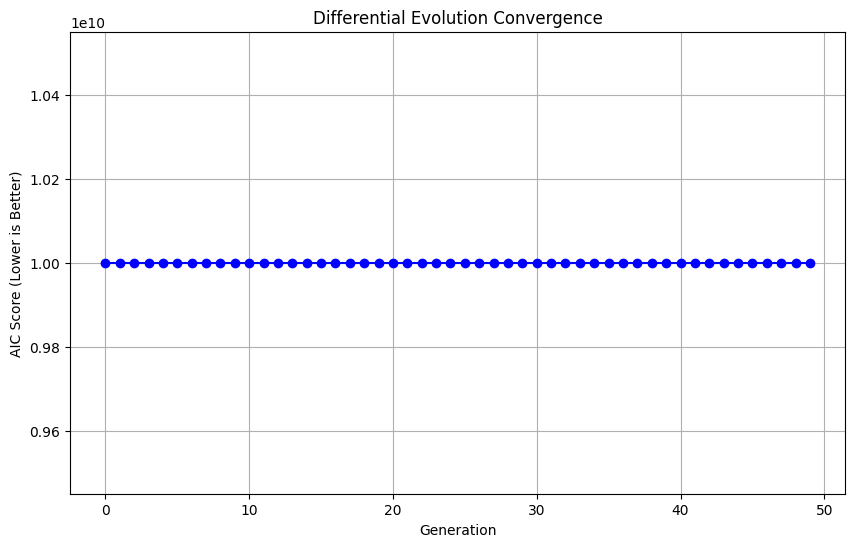

In [7]:
# --- 3. Execution & Visualization ---

# Run DE
best_params, best_aic, history = differential_evolution(df, "Age", "Time", "Event")

print(f"\nFinal Result:\nPowers: {best_params}\nAIC: {best_aic}")

# Plotting the Convergence
plt.figure(figsize=(10, 6))
plt.plot(history, marker='o', linestyle='-', color='b')
plt.title('Differential Evolution Convergence')
plt.xlabel('Generation')
plt.ylabel('AIC Score (Lower is Better)')
plt.grid(True)
plt.show()